In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

import sys
sys.path.append('../')

import superstats as sup
import bayesflow as bf
import numpy as np
import jax

print(jax.devices())

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


[CudaDevice(id=0)]


## Questions

- Plotting funs:
    + should marignal always be an arg?
    + what about spagetti
    + uncertainty_fun
    + etc.

## Todos

- Proper defaults for all priors
- Discuss best practice for defaults
    + e.g. plotting
    + what about default and then check if none and set default


- Context
- Augmentation
- Switch to new NRMSE impementation

docstring should be more extensive. what should go into kwargs and what should be exposed to user

## Specify Prior

In [3]:
joint_prior = sup.prior.JointPrior(
    v = sup.transition.RandomWalk(
            bounds=(-1.0, 1.0),
            sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
            delta=sup.prior.Prior(dist="halfnormal", scale=0.02),
            initial_prior=sup.prior.Prior(dist="normal", low=0.0, high=1.0)
        ),
    a = sup.transition.Mixture(
        transitions=[
            sup.transition.AutoRegression(),
            sup.transition.Jump()
        ],
        mixture_weights=sup.prior.Prior(dist="dirichlet", alpha=[15.0, 1.5]),
        bounds=(0.0, 4.0)
    ),
    bias = 0.5,
    tau = sup.prior.Prior(dist="halfnormal", scale=0.15)
)

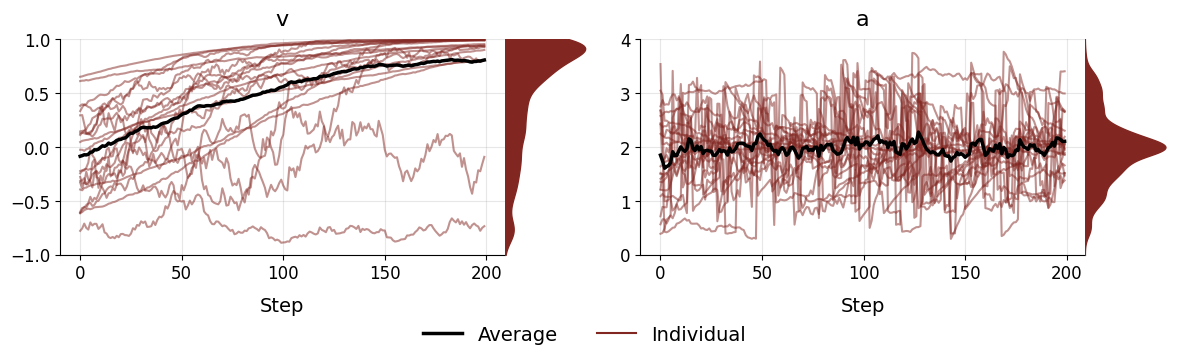

In [4]:
fig = joint_prior.plot_time_varying_prior()

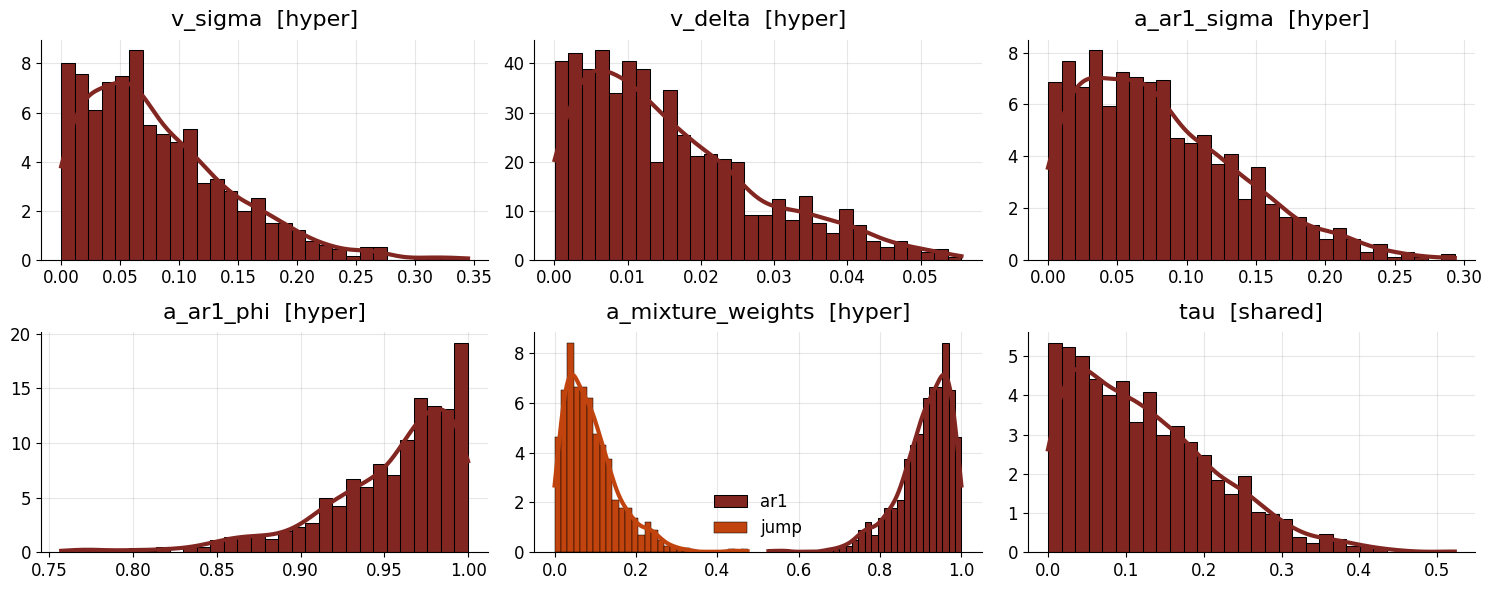

In [5]:
fig = joint_prior.plot_time_invariant_prior(num_cols=3)

In [ ]:
fig = joint_prior.plot_joint_prior()

## Specify Generative Model

In [6]:
ddm = sup.simulation.sample_ddm

In [7]:
generative_model = sup.simulation.GenerativeModel(
    prior=joint_prior,
    model=ddm,
)

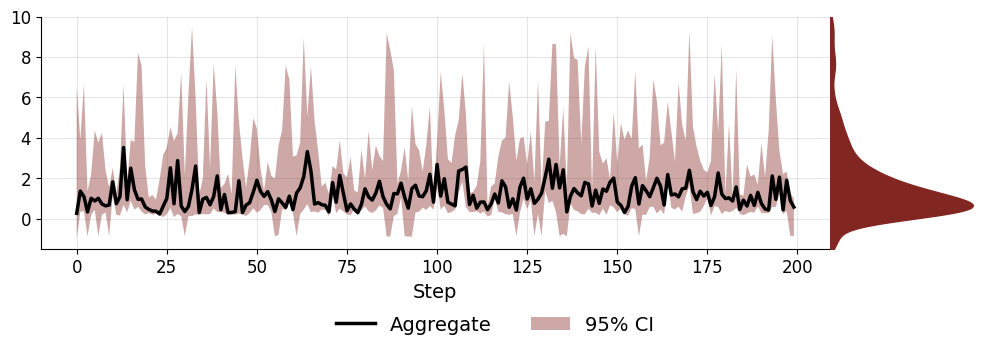

In [8]:
plot = generative_model.plot_push_forward(
    num_sim=5,
    num_steps=200,
    data_dim=0,
    kind="trajectory",
    aggregate_fun="median",
    uncertainty_fun="95ci",
    marginal=True,
    spaghetti=False,
    num_cols=3,
)


## Specify Workflow

- Data simulation should be outside
- Allow for kwargs
- Augmentation missing process, most simple just add randomly -1
- Missing augmentation class, with flexivblity and good defaults

In [9]:
workflow = sup.workflow.Workflow(
    simulator=generative_model,
    checkpoint_filepath="basic_ddm"
)

/scratch/schuma0018/slurm-job.16543476/ipykernel_1330939/181395889.py:1: UserWarning: restore_approximator=True but no model found at 'basic_ddm'. Starting with no trained model.
  workflow = sup.workflow.Workflow(
/scratch/schuma0018/slurm-job.16543476/ipykernel_1330939/181395889.py:1: UserWarning: restore_history=True but no history found at 'basic_ddm'. Starting with no history.
  workflow = sup.workflow.Workflow(


### Offline Training

In [ ]:
train_data = workflow.simulator.sample(
    batch_size=1000,
    num_steps=100,
    tile_to_steps=True
)
test_data = workflow.simulator.sample(
    batch_size=200,
    num_steps=100,
    tile_to_steps=True
)

In [ ]:
history = workflow.fit_offline(
    data=train_data,
    validation_data=test_data,
    epochs=2,
    batch_size=32
)

In [ ]:
plot = workflow.plot_history(history)

## Online Training

In [ ]:
history = workflow.fit_online(
    num_steps=300,
    epochs=75,
    num_batches_per_epoch=500,
    batch_size=32
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/75
500/500 ━━━━━━━━━━━━━━━━━━━━ 67s 101ms/step - loss: -1.2592
Epoch 2/75
500/500 ━━━━━━━━━━━━━━━━━━━━ 52s 103ms/step - loss: -2.8946
Epoch 3/75
208/500 ━━━━━━━━━━━━━━━━━━━━ 29s 100ms/step - loss: -3.2716

In [ ]:
plot = workflow.plot_history(history)

## Validation

In [ ]:
val_data = workflow.simulator.sample(
    batch_size=250,
    num_steps=300
)

In [ ]:
samples = workflow.sample(
    data=val_data['data'],
    num_samples=500,
)

### Time-varying Parameters

In [ ]:
fig = workflow.validate_time_varying(val_data, samples)

### Time-invariant Parameters

In [ ]:
fig_recovery, fig_calibration = workflow.validate_time_invariant(
    val_data,
    samples
)

## Data Fitting

In [ ]:
data = workflow.simulator.sample(5, 100)

In [ ]:
samples = workflow.sample(data['data'])

### Posterior Estimates

In [ ]:
local_keys = workflow.simulator.local_keys

fig = sup.diagnostics.plots.plot_time_varying_posterior(
    samples,
    local_keys,
    aggregate_fun="median",
    aggregate_strategy="no_epistemic",
    uncertainty_fun="95ci",
    # smoothing="sma",
    smoothing_window=5,
    marginal=True
)

In [ ]:
fig = sup.diagnostics.plots.plot_time_varying_posterior(
    samples,
    local_keys,
    aggregate_fun="median",
    aggregate_strategy="full_uncertainty",
    uncertainty_fun="95ci",
    smoothing="sma",
    smoothing_window=5,
    marginal=True
)

In [ ]:
keys = workflow.simulator.hyper_keys + workflow.simulator.shared_keys


fig = sup.diagnostics.plots.plot_time_invariant_posterior(
    samples,
    keys,
    aggregate=True
)

### Posterior Re-simulation

In [ ]:
pred_data = workflow.resimulate_posterior(samples, num_sims=10)


In [ ]:
fig = sup.diagnostics.plots.plot_posterior_resimulation(
    pred_data,
    data['data'],
    data_dim=0,
    kind="trajectory",
    aggregate_fun="median",
    aggregate_strategy="full_uncertainty",
    uncertainty_fun="95ci",
    spaghetti=True,
    # marginal=True,
    smoothing="sma",
    smoothing_window=2
)